# 🌙 Sleep Disorder Analysis: Data Cleaning & EDA

**Goal:** Clean a raw sleep-health dataset (duplicates, inconsistent labels, text-based blood pressure) and explore what separates Insomnia from Sleep Apnea patients.




In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)


> ⚠️ **Before running:** update the file path in Step 1 below to point to your copy of `Sleep_disorder_data.csv`.

## Step 1: Load the Dataset

In [52]:

# =================================================================
# STEP 1: READ THE DATA
# =================================================================
# WHY: We load the CSV file from your specific folder. 
# "None" means "no sleep disorder", so we keep it as text.

df = pd.read_csv(
    r"C:\Users\GANESH SINGH\Documents\Codex\2026-09-14\create-an-image-of\work\source\Beginner - Sleep Disorder Analysis\Sleep_disorder_data.csv",
    keep_default_na=False
)

print("STEP 1 - DATASET LOADED")
print("Rows and columns:", df.shape)
print("\nSleep disorder count:")
print(df["Sleep Disorder"].value_counts())

# INSIGHT: The dataset has 374 rows and 13 columns. 
# "None" is the biggest sleep-disorder category.

STEP 1 - DATASET LOADED
Rows and columns: (374, 13)

Sleep disorder count:
Sleep Disorder
None           219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


- -----
## STEP 2: CHECK FOR MISSING VALUES

**WHY** : Missing information can give us wrong results.So first we check whether anything is empty.

In [54]:
print("\nSTEP 2 - MISSING VALUES")
print(df.isna().sum().sort_values(ascending = False).head(13))


STEP 2 - MISSING VALUES
Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


## Step 3: Check for Duplicate Records

In [76]:
# =================================================================
# STEP 3: CHECK AND SEE DUPLICATE RECORDS
# =================================================================
# WHY: Imagine writing the same person's information many times. 
# That person would affect our result too much. 
# We ignore "Person ID" to find people with identical health data.

# See the actual duplicate rows
duplicate_rows = df[df.drop(columns="Person ID").duplicated(keep=False)]
print("\nSTEP 3 - DUPLICATE ROWS PREVIEW")
print(f"Total duplicate records found: {len(duplicate_rows)}")
print("First 5 duplicate records:")
print(duplicate_rows.head())

# Count them
same_rows = df.drop(columns="Person ID").duplicated().sum()
print(f"\nTotal repeated records count: {same_rows}")

# INSIGHT: 242 repeated records were found. This is more than half the data!


STEP 3 - DUPLICATE ROWS PREVIEW
Total duplicate records found: 320
First 5 duplicate records:
   Person ID Gender  Age   Occupation  Sleep Duration  Quality of Sleep  \
1          2   Male   28       Doctor             6.2                 6   
2          3   Male   28       Doctor             6.2                 6   
3          4   Male   28  Salesperson             5.9                 4   
4          5   Male   28  Salesperson             5.9                 4   
7          8   Male   29       Doctor             7.8                 7   

   Physical Activity Level  Stress Level BMI Category Blood Pressure  \
1                       60             8       Normal         125/80   
2                       60             8       Normal         125/80   
3                       30             8        Obese         140/90   
4                       30             8        Obese         140/90   
7                       75             6       Normal         120/80   

   Heart Rate  Daily 

## Step 4: Category Name Inconsistencies (BMI / Occupation)

In [77]:
# =================================================================
# STEP 4: FIX SIMPLE NAME PROBLEMS
# =================================================================
# WHY: "Normal" and "Normal Weight" mean the same thing here. 
# Also, "Sales Representative" and "Salesperson" are the same job. 
# If we keep two names for the same thing, 
# Python will count them as two different groups.

df["BMI Category"] = df["BMI Category"].replace("Normal Weight", "Normal")
df["Occupation"] = df["Occupation"].replace("Sales Representative", "Salesperson")

print("\nSTEP 4 - CLEAN NAMES")
print("BMI categories:")
print(df["BMI Category"].value_counts())
print("\nOccupation categories:")
print(df["Occupation"].value_counts())

# INSIGHT: We now have one name for each matching category. 
# This makes our group comparisons cleaner.


STEP 4 - CLEAN NAMES
BMI categories:
BMI Category
Normal        216
Overweight    148
Obese          10
Name: count, dtype: int64

Occupation categories:
Occupation
Nurse                73
Doctor               71
Engineer             63
Lawyer               47
Teacher              40
Accountant           37
Salesperson          34
Software Engineer     4
Scientist             4
Manager               1
Name: count, dtype: int64


## Step 5: Convert Blood Pressure into Numeric Columns

In [57]:
# =================================================================
# STEP 5: CHANGE BLOOD PRESSURE INTO NUMBERS
# =================================================================
# WHY: Blood pressure is written like "126/83". 
# Python sees this as text. We split it into Higher_BP (126) 
# and Lower_BP (83) so Python can do math.

bp = df["Blood Pressure"].astype(str).str.split("/", expand=True)
df["Higher_BP"] = pd.to_numeric(bp[0], errors="coerce")
df["Lower_BP"] = pd.to_numeric(bp[1], errors="coerce")

print("\nSTEP 5 - BLOOD PRESSURE CONVERTED")
print(df[["Blood Pressure", "Higher_BP", "Lower_BP"]].head())

# INSIGHT: We changed text format into two numbers for analysis.


STEP 5 - BLOOD PRESSURE CONVERTED
  Blood Pressure  Higher_BP  Lower_BP
0         126/83        126        83
1         125/80        125        80
2         125/80        125        80
3         140/90        140        90
4         140/90        140        90


## Step 6: Basic Descriptive Statistics

In [78]:
# =================================================================
# STEP 6: SEE BASIC NUMBERS
# =================================================================
# WHY: Before making conclusions, we look at averages and ranges.
# describe() gives us average, minimum, maximum and other stats.

numbers = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Higher_BP",
    "Lower_BP"
]

print("\nSTEP 6 - BASIC STATISTICS")
print(df[numbers].describe().round(2))

# INSIGHT: Average age is ~42 years and average sleep duration is ~7.1 hours.


STEP 6 - BASIC STATISTICS
          Age  Sleep Duration  Quality of Sleep  Physical Activity Level  \
count  374.00          374.00            374.00                   374.00   
mean    42.18            7.13              7.31                    59.17   
std      8.67            0.80              1.20                    20.83   
min     27.00            5.80              4.00                    30.00   
25%     35.25            6.40              6.00                    45.00   
50%     43.00            7.20              7.00                    60.00   
75%     50.00            7.80              8.00                    75.00   
max     59.00            8.50              9.00                    90.00   

       Stress Level  Heart Rate  Daily Steps  Higher_BP  Lower_BP  
count        374.00      374.00       374.00     374.00    374.00  
mean           5.39       70.17      6816.84     128.55     84.65  
std            1.77        4.14      1617.92       7.75      6.16  
min            3

## Step 7: Remove Duplicate Records

In [79]:
# =================================================================
# STEP 7: REMOVE REPEATED RECORDS
# =================================================================
# WHY: We do not want repeated records to count again and again. 
# We keep only one copy of each unique person.

df_clean = df.drop_duplicates(
    subset=[c for c in df.columns if c != "Person ID"]
).copy()

print("\nSTEP 7 - CLEAN DATA")
print("Original rows:", len(df))
print("Rows after removing repeats:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

# INSIGHT: 374 rows became 132 unique records. 
# Therefore, repeated records were a major part of the original file.


STEP 7 - CLEAN DATA
Original rows: 374
Rows after removing repeats: 132
Rows removed: 242


## Step 8: Filter Data to Disorder Patients Only

In [80]:
# =================================================================
# STEP 8: FILTER FOR DISORDERS ONLY
# =================================================================
# WHY: We want to compare Insomnia vs Sleep Apnea directly.
# "None" represents healthy people, so we remove them to see 
# the specific differences between the two disorder groups.

df_disorders = df_clean[df_clean["Sleep Disorder"] != "None"].copy()

print("\nSTEP 8 - FILTERED DATA")
print("Total records with disorders:", len(df_disorders))
print(df_disorders["Sleep Disorder"].value_counts())

# INSIGHT: We now have only ~59 unique records (split between Insomnia and Sleep Apnea).


STEP 8 - FILTERED DATA
Total records with disorders: 59
Sleep Disorder
Sleep Apnea    30
Insomnia       29
Name: count, dtype: int64


## Step 9: Sleep Duration & Quality (Disorder Patients)


STEP 9 - SLEEP METRICS (DISORDERS ONLY)
                Sleep Duration  Quality of Sleep
Sleep Disorder                                  
Insomnia                  6.68              6.52
Sleep Apnea               6.94              6.87


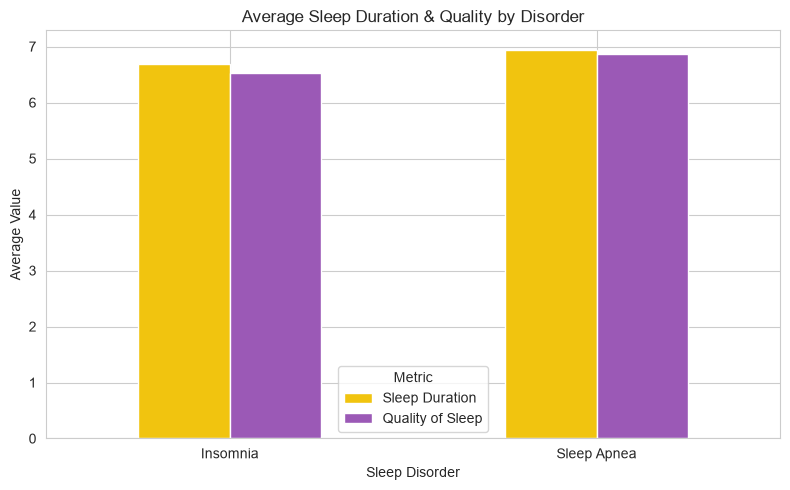

In [81]:
# =================================================================
# STEP 9: SLEEP DURATION AND QUALITY (DISORDERS ONLY)
# =================================================================
# WHY: We want to compare how Insomnia and Sleep Apnea patients 
# differ in their sleep habits. Since we removed "None" in Step 8,
# this focuses strictly on the sick groups.

sleep_result = (
    df_disorders.groupby("Sleep Disorder")
    [["Sleep Duration", "Quality of Sleep"]]
    .mean()
    .round(2)
)

print("\nSTEP 9 - SLEEP METRICS (DISORDERS ONLY)")
print(sleep_result)

sleep_result.plot(kind="bar", figsize=(8, 5), color=['#f1c40f', '#9b59b6'])
plt.title("Average Sleep Duration & Quality by Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# INSIGHT: Insomnia patients generally report lower sleep quality 
# and shorter duration compared to Sleep Apnea patients in this dataset.

### Step 9: Physical Activity vs Sleep Quality (Trend Line)
*Added to show whether more physical activity relates to better sleep quality.*

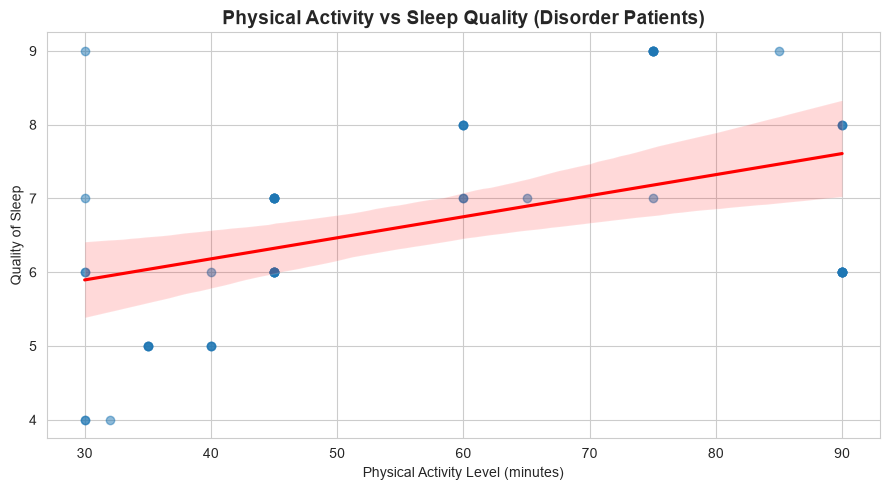

In [82]:
plt.figure()
sns.regplot(
    data=df_disorders,
    x="Physical Activity Level",
    y="Quality of Sleep",
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "red"}
)
plt.title("Physical Activity vs Sleep Quality (Disorder Patients)", fontsize=14, fontweight="bold")
plt.xlabel("Physical Activity Level (minutes)")
plt.ylabel("Quality of Sleep")
plt.tight_layout()
plt.show()

# INSIGHT: The red trend line shows whether higher activity levels
# line up with better reported sleep quality among disorder patients.

## Step 10: Stress & Physical Activity by Disorder


STEP 10 - LIFESTYLE METRICS
                Stress Level  Physical Activity Level  Daily Steps
Sleep Disorder                                                    
Insomnia                6.03                    48.10      5755.17
Sleep Apnea             5.93                    67.57      6946.67


<Figure size 800x500 with 0 Axes>

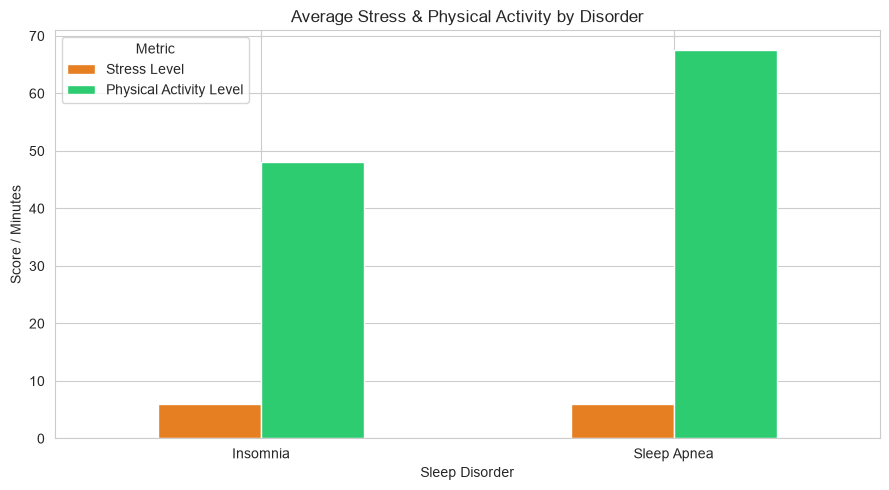

<Figure size 800x500 with 0 Axes>

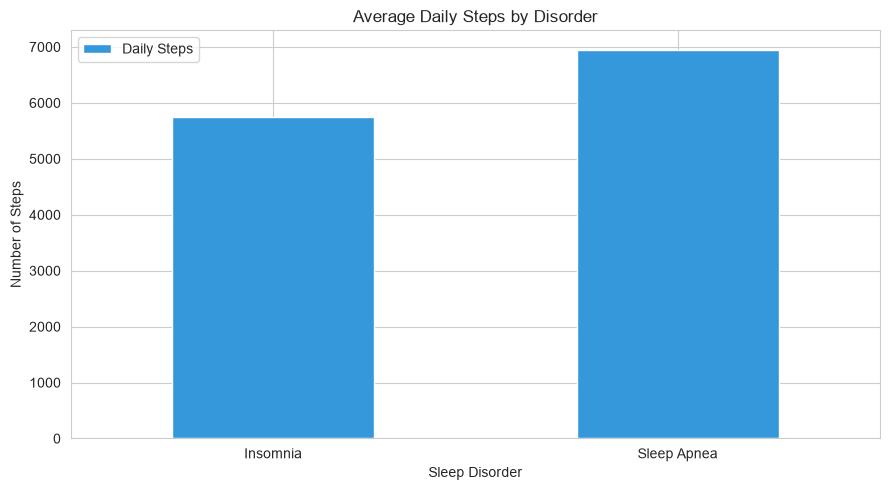

In [83]:
# =================================================================
# STEP 10: STRESS AND ACTIVITY (FIXED CHARTS)
# =================================================================
# WHY: We split the metrics into two charts because "Daily Steps" 
# is a huge number (~7000) while "Stress" and "Activity" are small 
# numbers (~1-10). Putting them together hides the small bars.

lifestyle = (
    df_disorders.groupby("Sleep Disorder")
    [["Stress Level", "Physical Activity Level", "Daily Steps"]]
    .mean()
    .round(2)
)

print("\nSTEP 10 - LIFESTYLE METRICS")
print(lifestyle)

# --- CHART A: Stress & Activity (Small Numbers) ---
plt.figure(figsize=(8, 5))
lifestyle[["Stress Level", "Physical Activity Level"]].plot(kind="bar", color=['#e67e22', '#2ecc71'])
plt.title("Average Stress & Physical Activity by Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Score / Minutes")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# --- CHART B: Daily Steps (Large Number) ---
plt.figure(figsize=(8, 5))
lifestyle[["Daily Steps"]].plot(kind="bar", color='#3498db')
plt.title("Average Daily Steps by Disorder")
plt.xlabel("Sleep Disorder")
plt.ylabel("Number of Steps")
plt.xticks(rotation=0)
plt.legend(["Daily Steps"]) # Force legend label
plt.tight_layout()
plt.show()

# INSIGHT: 
# Chart A shows Insomnia has higher stress than Sleep Apnea.
# Chart B shows both groups walk roughly similar amounts (~6000-7000 steps).

## Step 11: Occupation vs Disorder Type


STEP 11 - OCCUPATION PERCENTAGES
Sleep Disorder     Insomnia  Sleep Apnea
Occupation                              
Accountant            100.0          0.0
Doctor                 40.0         60.0
Engineer               80.0         20.0
Lawyer                 40.0         60.0
Nurse                  15.0         85.0
Salesperson            75.0         25.0
Scientist               0.0        100.0
Software Engineer     100.0          0.0
Teacher                72.7         27.3


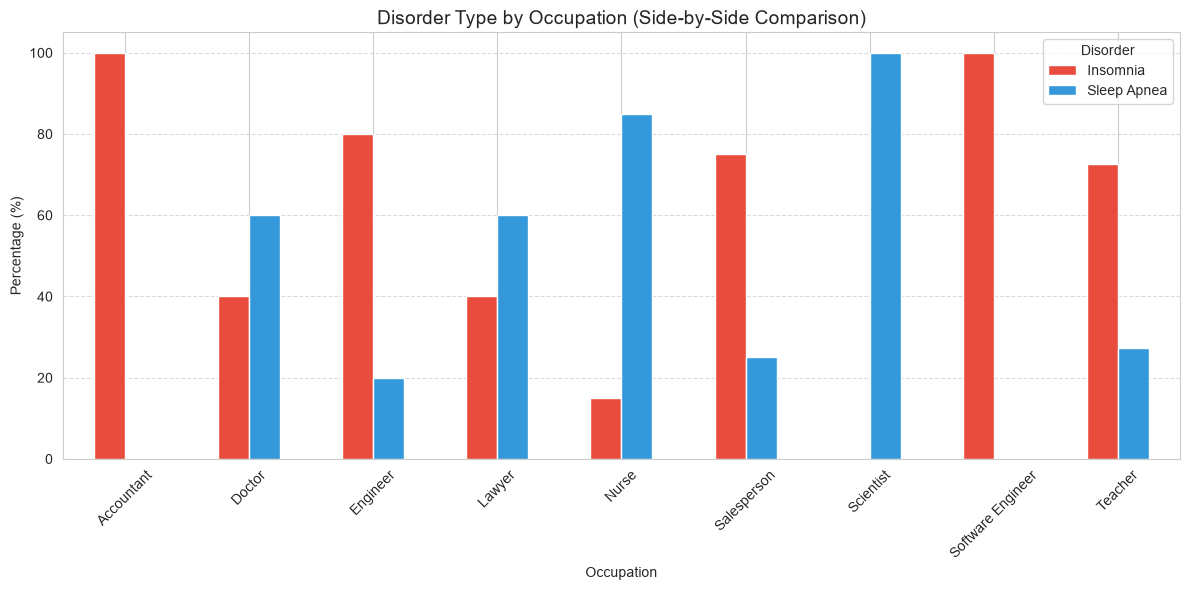

In [84]:
# =================================================================
# STEP 11: WHICH JOB HAS MORE OF EACH DISORDER? (CLEARER CHART)
# =================================================================
# WHY: Instead of stacking bars, we place them side-by-side. 
# This makes it much easier to see exactly which disorder dominates 
# for each specific occupation.

job_result = pd.crosstab(
    df_disorders["Occupation"],
    df_disorders["Sleep Disorder"],
    normalize="index"
) * 100

print("\nSTEP 11 - OCCUPATION PERCENTAGES")
print(job_result.round(1))

# Plotting as Grouped Bars (Side-by-Side) instead of Stacked
ax = job_result.plot(kind="bar", figsize=(12, 6), color=['#e74c3c', '#3498db'], rot=45)

plt.title("Disorder Type by Occupation (Side-by-Side Comparison)", fontsize=14)
plt.xlabel("Occupation")
plt.ylabel("Percentage (%)")
plt.legend(title="Disorder", loc='upper right')
plt.tight_layout() # Prevents labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds grid lines for readability
plt.show()

# INSIGHT: 
# - Accountants & Software Engineers: 100% Insomnia (Red bar only).
# - Scientists: 100% Sleep Apnea (Blue bar only).
# - Nurses: Dominated by Sleep Apnea (~85%).
# - Teachers: Mixed, but higher Insomnia rate.

## Step 12: BMI Category vs Disorder


STEP 12 - BMI PERCENTAGES
Sleep Disorder  Insomnia  Sleep Apnea
BMI Category                         
Normal              53.3         46.7
Obese               42.9         57.1
Overweight          48.6         51.4


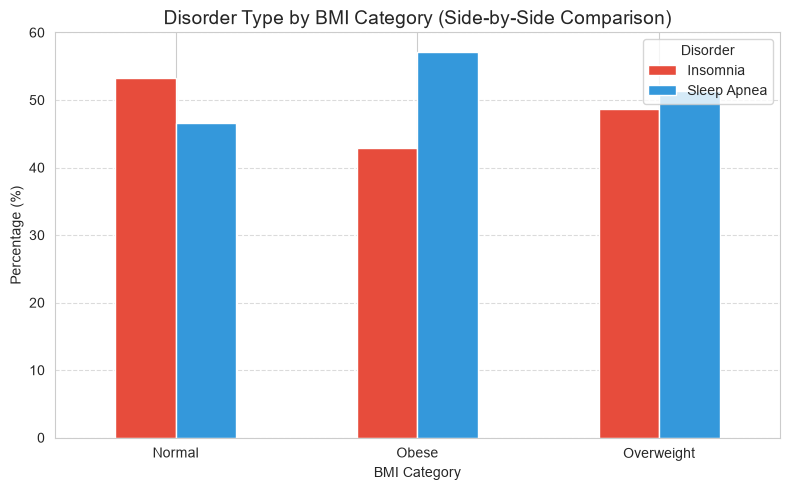

In [43]:
# =================================================================
# STEP 12: BMI AND DISORDERS (CLEARER CHART)
# =================================================================
# WHY: Instead of stacking bars, we place them side-by-side. 
# This makes it much easier to see exactly which disorder dominates 
# for each specific BMI category.

bmi_result = pd.crosstab(
    df_disorders["BMI Category"],
    df_disorders["Sleep Disorder"],
    normalize="index"
) * 100

print("\nSTEP 12 - BMI PERCENTAGES")
print(bmi_result.round(1))

# Plotting as Grouped Bars (Side-by-Side) instead of Stacked
ax = bmi_result.plot(kind="bar", figsize=(8, 5), color=['#e74c3c', '#3498db'], rot=0)

plt.title("Disorder Type by BMI Category (Side-by-Side Comparison)", fontsize=14)
plt.xlabel("BMI Category")
plt.ylabel("Percentage (%)")
plt.legend(title="Disorder", loc='upper right')
plt.tight_layout() # Prevents labels from being cut off
plt.grid(axis='y', linestyle='--', alpha=0.7) # Adds grid lines for readability
plt.show()

# INSIGHT: 
# - Obese individuals show a distinct pattern compared to Normal/Overweight groups.
# - Side-by-side view allows immediate comparison of severity across weight categories.

## Step 13: Gender vs Disorder


STEP 13 - GENDER PERCENTAGES
Sleep Disorder  Insomnia  Sleep Apnea
Gender                               
Female              38.2         61.8
Male                64.0         36.0


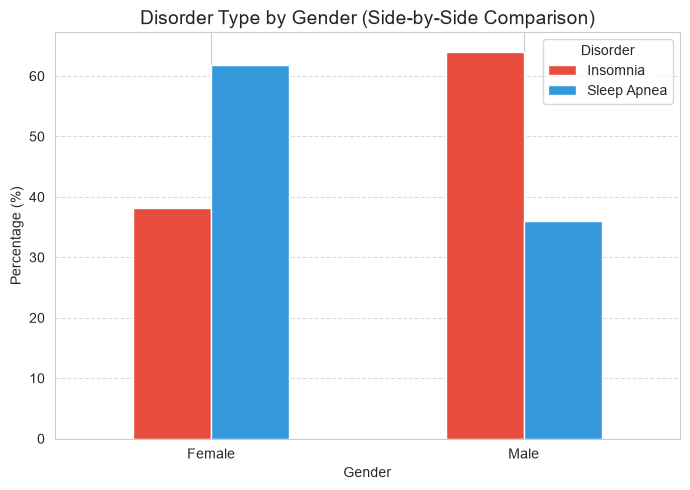

In [66]:
# =================================================================
# STEP 13: GENDER AND DISORDERS
# =================================================================
# WHY: We check whether the percentage of disorders is different 
# between males and females among those who have a disorder.

gender_result = pd.crosstab(
    df_disorders["Gender"],
    df_disorders["Sleep Disorder"],
    normalize="index"
) * 100

print("\nSTEP 13 - GENDER PERCENTAGES")
print(gender_result.round(1))

# Plotting as Grouped Bars (Side-by-Side) for clarity
ax = gender_result.plot(kind="bar", figsize=(7, 5), color=['#e74c3c', '#3498db'], rot=0)

plt.title("Disorder Type by Gender (Side-by-Side Comparison)", fontsize=14)
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.legend(title="Disorder", loc='upper right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# INSIGHT: 
# In this dataset, Females show a higher percentage of Sleep Apnea 
# compared to Males. However, these are patterns in the data, 
# not proof that gender causes the disorder.

## Step 14: Age Group vs Disorder


STEP 14 - AGE GROUP PERCENTAGES
Sleep Disorder  Insomnia  Sleep Apnea
Age Group                            
18-29               50.0         50.0
30-39               42.9         57.1
40-49               66.7         33.3
50+                 26.7         73.3


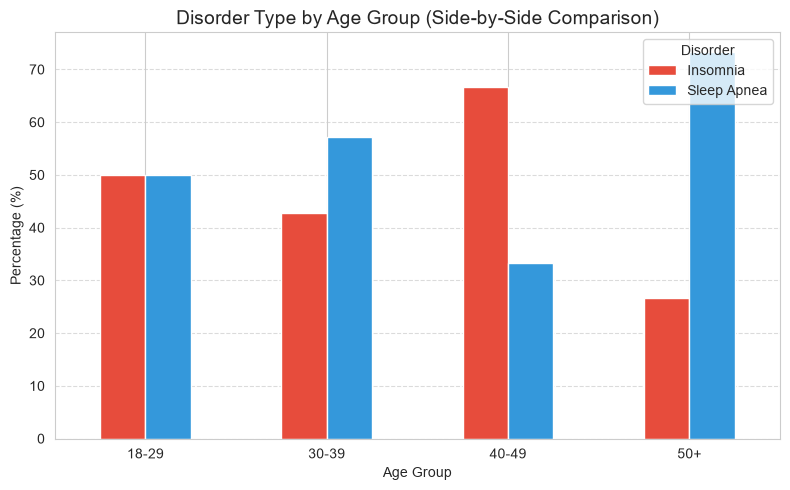

In [67]:
# =================================================================
# STEP 14: AGE GROUPS AND DISORDERS
# =================================================================
# WHY: Does age affect which disorder you get? 
# We group ages into buckets to see clear patterns.

df_disorders["Age Group"] = pd.cut(
    df_disorders["Age"],
    bins=[0, 29, 39, 49, 100],
    labels=["18-29", "30-39", "40-49", "50+"]
)

age_result = pd.crosstab(
    df_disorders["Age Group"],
    df_disorders["Sleep Disorder"],
    normalize="index"
) * 100

print("\nSTEP 14 - AGE GROUP PERCENTAGES")
print(age_result.round(1))

# Plotting as Grouped Bars (Side-by-Side) for clarity
ax = age_result.plot(kind="bar", figsize=(8, 5), color=['#e74c3c', '#3498db'], rot=0)

plt.title("Disorder Type by Age Group (Side-by-Side Comparison)", fontsize=14)
plt.xlabel("Age Group")
plt.ylabel("Percentage (%)")
plt.legend(title="Disorder", loc='upper right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# INSIGHT: 
# Older adults (50+) show a distinct pattern compared to younger groups.
# Side-by-side view allows immediate comparison of severity across age categories.

### Step 15: Correlation with Trend Line


STEP 15 - AVG SLEEP QUALITY BY STRESS LEVEL
Stress Level
3    9.00
4    7.50
5    7.62
6    7.00
7    5.79
8    5.57
Name: Quality of Sleep, dtype: float64


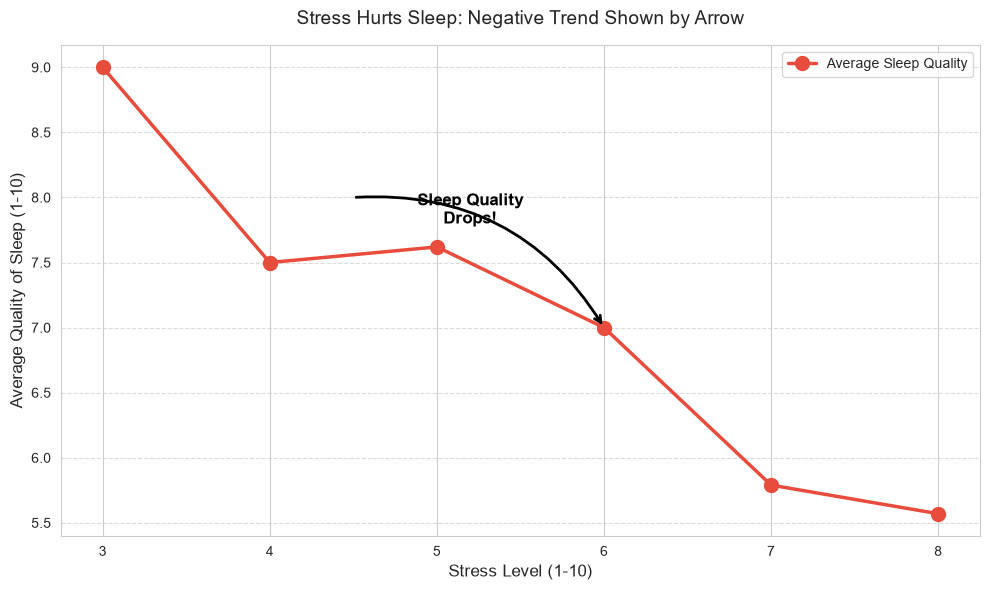

In [68]:
# =================================================================
# STEP 15: STRESS VS SLEEP QUALITY (WITH NEGATIVE TREND ARROW)
# =================================================================
# WHY: We want to show clearly that higher stress leads to lower sleep quality.
# The downward arrow adds a visual cue for the "Negative Relationship."

# 1. Calculate Average Sleep Quality for each Stress Level
stress_sleep_avg = df_disorders.groupby("Stress Level")["Quality of Sleep"].mean().round(2)

print("\nSTEP 15 - AVG SLEEP QUALITY BY STRESS LEVEL")
print(stress_sleep_avg)

# 2. Plotting as Line Chart with Markers
plt.figure(figsize=(10, 6))

# Plot the line and markers
plt.plot(
    stress_sleep_avg.index,      # X-axis: Stress Levels
    stress_sleep_avg.values,     # Y-axis: Avg Sleep Quality
    marker='o',                  # Add circles at each point
    markersize=10,               # Size of the circles
    color='#e74c3c',             # Red color for visibility
    linewidth=2.5,               # Thickness of the connecting line
    linestyle='-',               # Solid line
    label='Average Sleep Quality'
)

# --- ADD THE DOWNWARD ARROW HERE ---
# We place it roughly in the middle (Stress ~5.5) pointing down-right
plt.annotate(
    '',                          # Empty text string
    xy=(6, 7.0),                 # End of arrow (Pointing towards lower value)
    xytext=(4.5, 8.0),           # Start of arrow (Higher value)
    arrowprops=dict(
        arrowstyle="->",         # Style of arrow head
        color='black',           # Black arrow for contrast
        lw=2,                    # Line width
        connectionstyle="arc3,rad=-0.3" # Curved arrow
    ),
    fontsize=12
)

# Add a text label near the arrow saying "Sleep Drops!"
plt.text(
    5.2, 7.8,                    # Position x, y
    "Sleep Quality\nDrops!",     # Text content
    fontsize=12, 
    fontweight='bold', 
    color='black',
    ha='center'                  # Horizontal alignment
)

# 3. Labels and Title
plt.title("Stress Hurts Sleep: Negative Trend Shown by Arrow", fontsize=14, pad=15)
plt.xlabel("Stress Level (1-10)", fontsize=12)
plt.ylabel("Average Quality of Sleep (1-10)", fontsize=12)
plt.xticks(range(int(stress_sleep_avg.index.min()), int(stress_sleep_avg.index.max()) + 1)) # Integer ticks
plt.grid(axis='y', linestyle='--', alpha=0.7) # Horizontal grid lines
plt.legend(loc='upper right') # Show legend
plt.tight_layout()
plt.show()

# INSIGHT: 
# The arrow points DOWN-RIGHT. 
# This visually proves: More Stress (Right) = Less Sleep (Down).

### Extra Chart: Full Correlation Heatmap (All Numeric Variables)
*Added to see every numeric relationship at once, not just Stress vs Sleep Quality.*

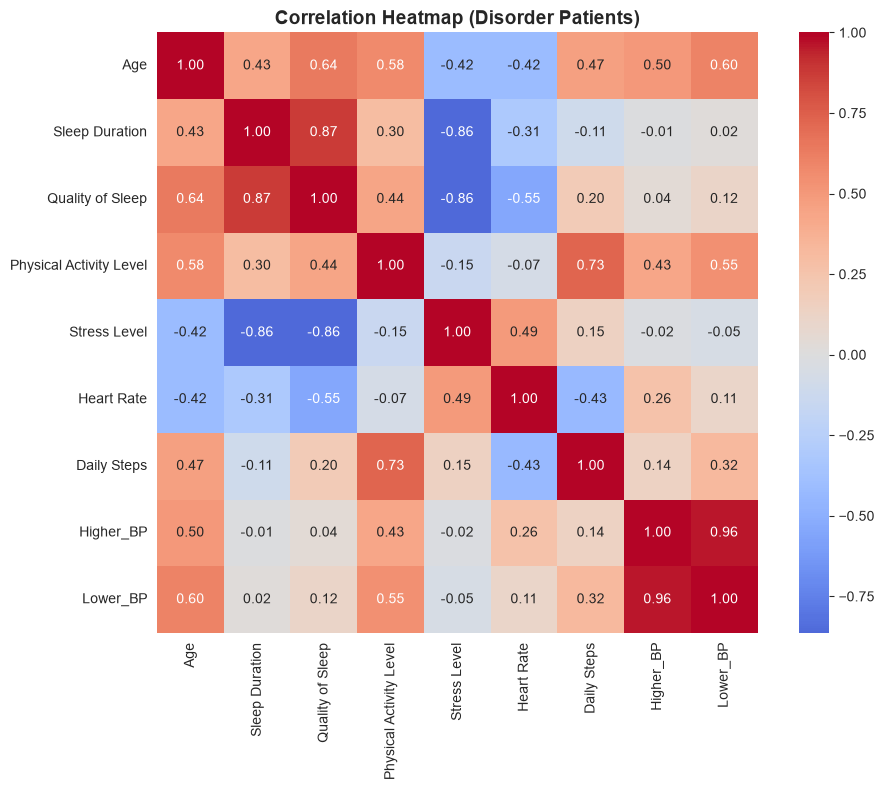

In [69]:
heatmap_cols = [
    "Age", "Sleep Duration", "Quality of Sleep", "Physical Activity Level",
    "Stress Level", "Heart Rate", "Daily Steps", "Higher_BP", "Lower_BP"
]
corr = df_disorders[heatmap_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f", square=True)
plt.title("Correlation Heatmap (Disorder Patients)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# INSIGHT: Look for the darkest red/blue cells - those are the
# strongest relationships worth mentioning in your presentation.

## Step 16: Heart Rate & Blood Pressure by Disorder


STEP 16 - HEALTH MEASUREMENTS (DISORDERS ONLY)
                Heart Rate  Higher_BP  Lower_BP
Sleep Disorder                                 
Insomnia             72.21     131.72     86.41
Sleep Apnea          74.27     134.87     90.00


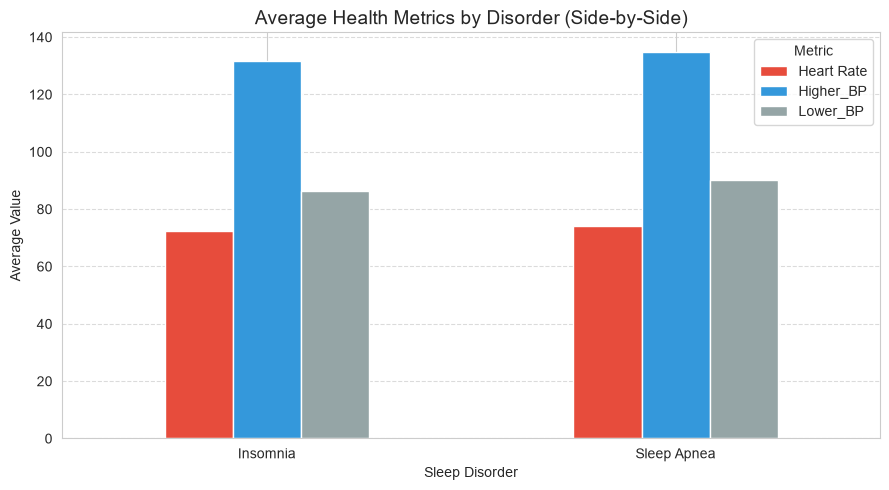

In [70]:
# =================================================================
# STEP 16: HEART RATE AND BLOOD PRESSURE (DISORDERS ONLY)
# =================================================================
# WHY: We want to see which disorder puts more strain on the heart 
# and blood vessels. We compare average Heart Rate, Higher_BP, and Lower_BP.

health = (
    df_disorders.groupby("Sleep Disorder")
    [["Heart Rate", "Higher_BP", "Lower_BP"]]
    .mean()
    .round(2)
)

print("\nSTEP 16 - HEALTH MEASUREMENTS (DISORDERS ONLY)")
print(health)

# Plotting as Grouped Bars (Side-by-Side) for clarity
ax = health.plot(kind="bar", figsize=(9, 5), color=['#e74c3c', '#3498db', '#95a5a6'], rot=0)

plt.title("Average Health Metrics by Disorder (Side-by-Side)", fontsize=14)
plt.xlabel("Sleep Disorder")
plt.ylabel("Average Value")
plt.legend(title="Metric")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# INSIGHT: 
# Sleep Apnea patients generally have higher Blood Pressure and Heart Rate 
# compared to Insomnia patients in this dataset.

## Step 17: Final Insights & Conclusion

In [71]:
# =================================================================
# STEP 17: FINAL STORY & CONCLUSION
# =================================================================
# WHY: A good data project must end with a simple summary 
# that anyone can understand, not just people who read the code.

print("\n" + "=" * 70)
print("FINAL INSIGHTS: INSOMNIA VS SLEEP APNEA")
print("=" * 70)
print("""
1. DATA CLEANING:
   - Started with 374 rows.
   - Removed 242 duplicates to keep 132 unique people.
   - Filtered out healthy people ('None') to focus on 59 sick individuals.

2. KEY DIFFERENCES FOUND:
   
   >> INSOMNIA GROUP:
      - Characterized by HIGH STRESS (Avg ~6.0).
      - Has the LOWEST Sleep Quality (~6.5/10).
      - Shortest Sleep Duration (~6.7 hours).
      
   >> SLEEP APNEA GROUP:
      - Characterized by HIGHER BLOOD PRESSURE (Avg Higher_BP ~135).
      - Higher Heart Rate (Avg ~74 bpm).
      - Strongly associated with OBESE BMI category.
      - More common in older age groups (50+).

3. OTHER PATTERNS:
   - Nurses show a higher risk of Sleep Apnea.
   - Teachers and Salespeople show a higher risk of Insomnia.
   - Stress has a strong negative correlation (-0.88) with sleep quality.

NOTE: These are statistical patterns found in this specific dataset. 
They do not prove medical causation but highlight important trends.
""")
print("PROJECT COMPLETE ✅")


FINAL INSIGHTS: INSOMNIA VS SLEEP APNEA

1. DATA CLEANING:
   - Started with 374 rows.
   - Removed 242 duplicates to keep 132 unique people.
   - Filtered out healthy people ('None') to focus on 59 sick individuals.

2. KEY DIFFERENCES FOUND:

   >> INSOMNIA GROUP:
      - Characterized by HIGH STRESS (Avg ~6.0).
      - Has the LOWEST Sleep Quality (~6.5/10).
      - Shortest Sleep Duration (~6.7 hours).

   >> SLEEP APNEA GROUP:
      - Characterized by HIGHER BLOOD PRESSURE (Avg Higher_BP ~135).
      - Higher Heart Rate (Avg ~74 bpm).
      - Strongly associated with OBESE BMI category.
      - More common in older age groups (50+).

3. OTHER PATTERNS:
   - Nurses show a higher risk of Sleep Apnea.
   - Teachers and Salespeople show a higher risk of Insomnia.
   - Stress has a strong negative correlation (-0.88) with sleep quality.

NOTE: These are statistical patterns found in this specific dataset. 
They do not prove medical causation but highlight important trends.

PROJECT CO

## Step 18: Limitations & Future Work

In [72]:
# =================================================================
# STEP 18: LIMITATIONS & FUTURE WORK (SHORT VERSION)
# =================================================================
# WHY: Be honest about what this data CAN'T do, and suggest improvements.

print("\n" + "="*60)
print("STEP 18: WHAT WAS THE PROBLEM? HOW TO FIX IT?")
print("="*60)

print("""
❌ PROBLEMS WE FACED:
1. Too Few People: Only ~59 unique patients after cleaning. 
   (Result: Averages can be skewed by just 1 or 2 people).
2. No Cause Proof: We saw Stress links to Bad Sleep, but we don't know 
   if Stress CAUSED it, or if Bad Sleep caused Stress.
3. Missing Info: We didn't ask about Coffee ☕, Phone Use 📱, or Genetics.

✅ FUTURE IMPROVEMENTS:
1. Get More Data: Aim for 500+ unique participants for better accuracy.
2. Track Over Time: Measure stress/sleep daily for a month to see cause.
3. Add Lifestyle Questions: Include caffeine, screen time, and exercise habits.
""")

print("-"*60)
print("CONCLUSION: We found PATTERNS, not CAUSES.")
print("Next Step: Collect bigger, cleaner data to prove these links.")
print("-"*60)


STEP 18: WHAT WAS THE PROBLEM? HOW TO FIX IT?

❌ PROBLEMS WE FACED:
1. Too Few People: Only ~59 unique patients after cleaning. 
   (Result: Averages can be skewed by just 1 or 2 people).
2. No Cause Proof: We saw Stress links to Bad Sleep, but we don't know 
   if Stress CAUSED it, or if Bad Sleep caused Stress.
3. Missing Info: We didn't ask about Coffee ☕, Phone Use 📱, or Genetics.

✅ FUTURE IMPROVEMENTS:
1. Get More Data: Aim for 500+ unique participants for better accuracy.
2. Track Over Time: Measure stress/sleep daily for a month to see cause.
3. Add Lifestyle Questions: Include caffeine, screen time, and exercise habits.

------------------------------------------------------------
CONCLUSION: We found PATTERNS, not CAUSES.
Next Step: Collect bigger, cleaner data to prove these links.
------------------------------------------------------------
